# Data Analysis Pipeline

ASOS, WU, OpenMesh (CML + PWS). Load or fetch → unified format → maps, plots, CML–PWS matching, rain detection.

## 1. Setup & Imports

Import required libraries and analysis functions for data processing, visualization, and analysis.

In [2]:
import sys
import warnings
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))
from analysis.pipeline import (
    get_default_paths,
    load_metadata,
    load_or_fetch_openmesh,
    load_or_fetch_data,
    prepare_analysis_data,
    display_sensors_map,
    display_weather_info,
    adjust_dates,
    plot_cml_rsl,
    filter_cml_links,
)
from analysis.analysis_functions import (
    find_nearest_pws_stations,
    prepare_detection_data,
    run_rolling_std_detection,
    plot_detection_results,
)
from analysis.plotting import (
    plot_weather_params,
    accumulation_plot,
    plot_subnetwork,
)
print("✓ Setup complete")

✓ Setup complete


## 2. Configuration

In [3]:
START_DATE = datetime(2024, 1, 1)
END_DATE   = datetime(2024, 1, 30)
ASOS_STATIONS = ['KLGA', 'KNYC', 'KJFK']
WU_STATIONS = 'all'
MODE = 'fetch'

print("=" * 70)
print("CONFIGURATION")
print("=" * 70)
print(f"Period: {START_DATE.date()} → {END_DATE.date()}")
print(f"Mode: {MODE.upper()}")
print(f"ASOS stations: {ASOS_STATIONS}")
print(f"WU stations: {WU_STATIONS}")
print("=" * 70)

CONFIGURATION
Period: 2024-01-01 → 2024-01-30
Mode: FETCH
ASOS stations: ['KLGA', 'KNYC', 'KJFK']
WU stations: all


## 3. Load Metadata

In [4]:
paths    = get_default_paths()
metadata = load_metadata(paths)

print("\nMetadata loaded:")
print(f"  ASOS: {len(metadata['asos'])} stations")
print(f"  WU: {len(metadata['wu'])} stations")
print(f"  OpenMesh Links: {len(metadata['openmesh_links'])} sublinks")

LOADING METADATA
✓ ASOS: 3 stations (ASOS_stations.csv)
✓ WU: 37 stations (pws_metadata.csv)
✓ OpenMesh Links: 103 sublinks (links_metadata.csv)

Metadata loaded:
  ASOS: 3 stations
  WU: 37 stations
  OpenMesh Links: 103 sublinks


## 4. Load/Fetch OpenMesh Data (CML & PWS)

`MODE`: load from files or fetch from Zenodo. `PWS_OPENMESH_SOURCE`: sample (Jan sample) or full (`pws_wu_os.nc`).

In [5]:
OPENMESH_MODE = 'load'        # 'fetch' or 'load'
PWS_OPENMESH_SOURCE = 'sample'   # 'sample' or 'full'

ds_links, links_meta, pws_data = load_or_fetch_openmesh(
    paths=paths, mode=OPENMESH_MODE, pws_source=PWS_OPENMESH_SOURCE
)

OPENMESH DATA
Mode: load
  Links: ds_openmesh.nc
  PWS (sample): pws_opensense_sample_jan.nc
✓ Links: 75 | PWS: 37 stations


## 5. Load/Fetch Weather Data (ASOS & WU)

In [ ]:
# Load or fetch ASOS and WU data.
WEATHER_DATA_MODE = 'fetch'

weather_data = load_or_fetch_data(
    mode            = WEATHER_DATA_MODE,
    start_date      = START_DATE,
    end_date        = END_DATE,
    asos_stations   = ASOS_STATIONS,
    wu_stations     = WU_STATIONS if WU_STATIONS != 'all' else None,
    asos_metadata   = metadata['asos'],
    wu_metadata     = metadata['wu'],
)


DATA ACQUISITION: FETCH
Period: 2024-01-01 → 2024-01-30

📡 ASOS: Fetching 3 specified stations
  Fetching ASOS for period: 2024-01-01 to 2024-01-30
  Stations: ['LGA', 'NYC', 'JFK']
FETCHING 1-MINUTE ASOS DATA
Period: 2024-01-01 to 2024-01-30

LGA (LaGuardia Airport):
  2024-01... ✓ 41,036 rows
  ✓ Total: 41,036 rows

NYC (Central Park):
  2024-01... 

## 6. Prepare Analysis Data

Combine all data sources into unified format:
- **ASOS**: Airport weather stations
- **WU**: Weather Underground PWS
- **OpenMesh**: CML links + PWS

`PWS_SOURCE`: which PWS to use — `'openmesh'` (Zenodo) or `'wu'` (API)


In [ ]:

PWS_SOURCE = 'openmesh' # 'wu' for fetched data from WU API
datasets = {
    'asos': {
        'raw': weather_data['asos'],
        'meta': metadata['asos']
    },
    'wu': {
        'raw': weather_data['wu'],
        'meta': metadata['wu']
    },
    'openmesh': {
        'raw': {'links': ds_links, 'pws': pws_data},
        'meta': {'links': links_meta, 'pws': metadata['wu']}  # PWS meta same as WU
    }
}

analysis_data = prepare_analysis_data(
    datasets=datasets,
    analysis_period=(START_DATE, END_DATE),
    pws_source='openmesh',
    parameters='all',
)
print("\n✓ Analysis data prepared")

Preparing Analysis Data (Source: openmesh)
Period: 2024-01-01 to 2024-01-30
ASOS Params: wind_direction (3), rainfall_amount (3), wind_speed (3), wind_gust (3), rainfall_rate (3), precip_type (3), dewpoint (3), precip_category (3), temperature (3)
PWS Params:  pressure (37), humidity (37), rainfall_amount (37), wind_direction (37), wind_speed (37), temperature (37), rainfall_rate (37)
CML Params:  rsl (102)
Skipping resampling.

✓ Analysis data prepared


## 7. Map Sensors

In [ ]:
fig, ax = display_sensors_map(
    links_meta=metadata['openmesh_links'],
    asos_meta=metadata['asos'],
    pws_meta=metadata['wu'],
    map_type='matplotlib',
    show_link_labels=False,
    asos_station_ids=['KLGA', 'KNYC'],
)

NameError: name 'display_sensors_map' is not defined

## 8. Display Weather Data

In [ ]:
display_weather_info()

adjust_dates_flag = True

if adjust_dates_flag:
    original_start = START_DATE
    original_end = END_DATE
    
    START_DATE, END_DATE = adjust_dates(analysis_data, START_DATE, END_DATE)
    
    print(f"\n📅 Date Range Adjustment:")
    print(f"  Original: {original_start.date()} → {original_end.date()}")
    print(f"  Adjusted: {START_DATE.date()} → {END_DATE.date()}")
    print("=" * 70)


DISPLAY WEATHER
### Display Precipitation :

📅 Date Range Adjustment:
  Original: 2024-01-01 → 2024-01-30
  Adjusted: 2024-01-15 → 2024-01-29


  ℹ Showing first 10 of 37 PWS stations


(<Figure size 1600x800 with 2 Axes>,
 array([<Axes: title={'center': 'ASOS - Temperature (°C) (3 stations)'}, ylabel='Temperature (°C)'>,
        <Axes: title={'center': 'PWS - Temperature (°C) (37 stations)'}, xlabel='Time', ylabel='Temperature (°C)'>],
       dtype=object))

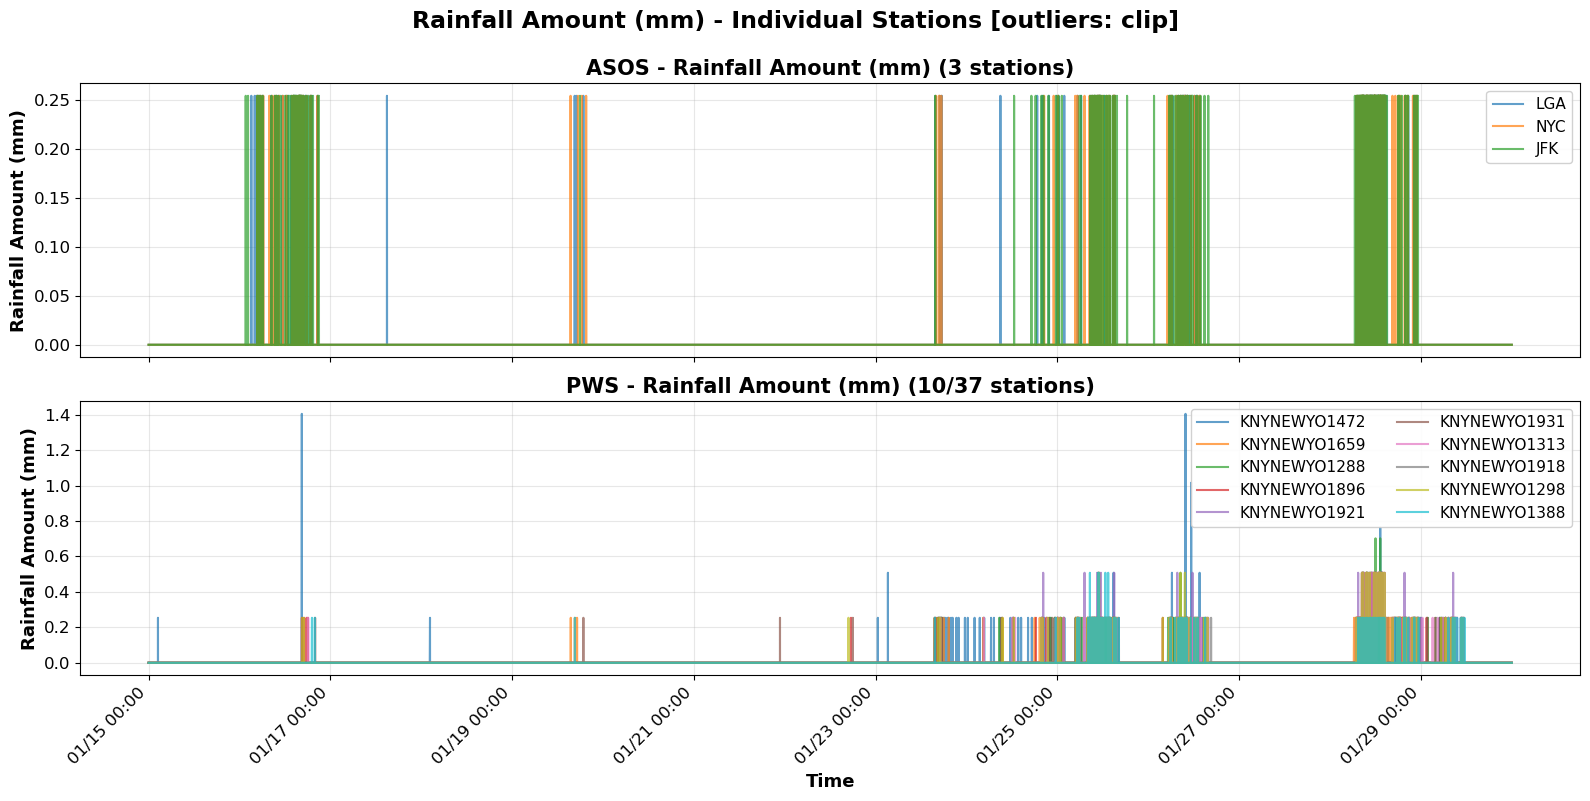

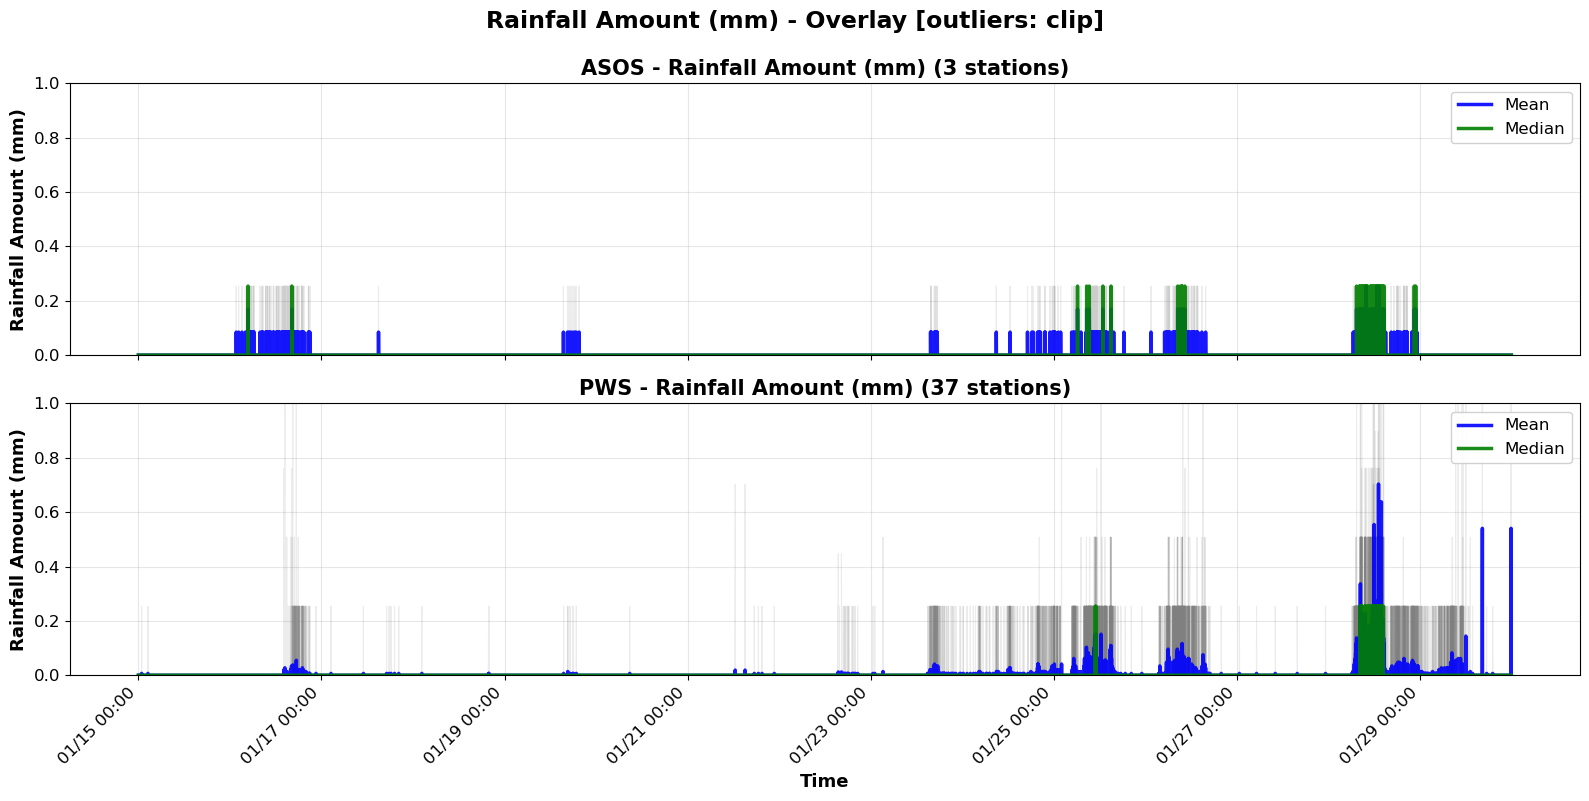

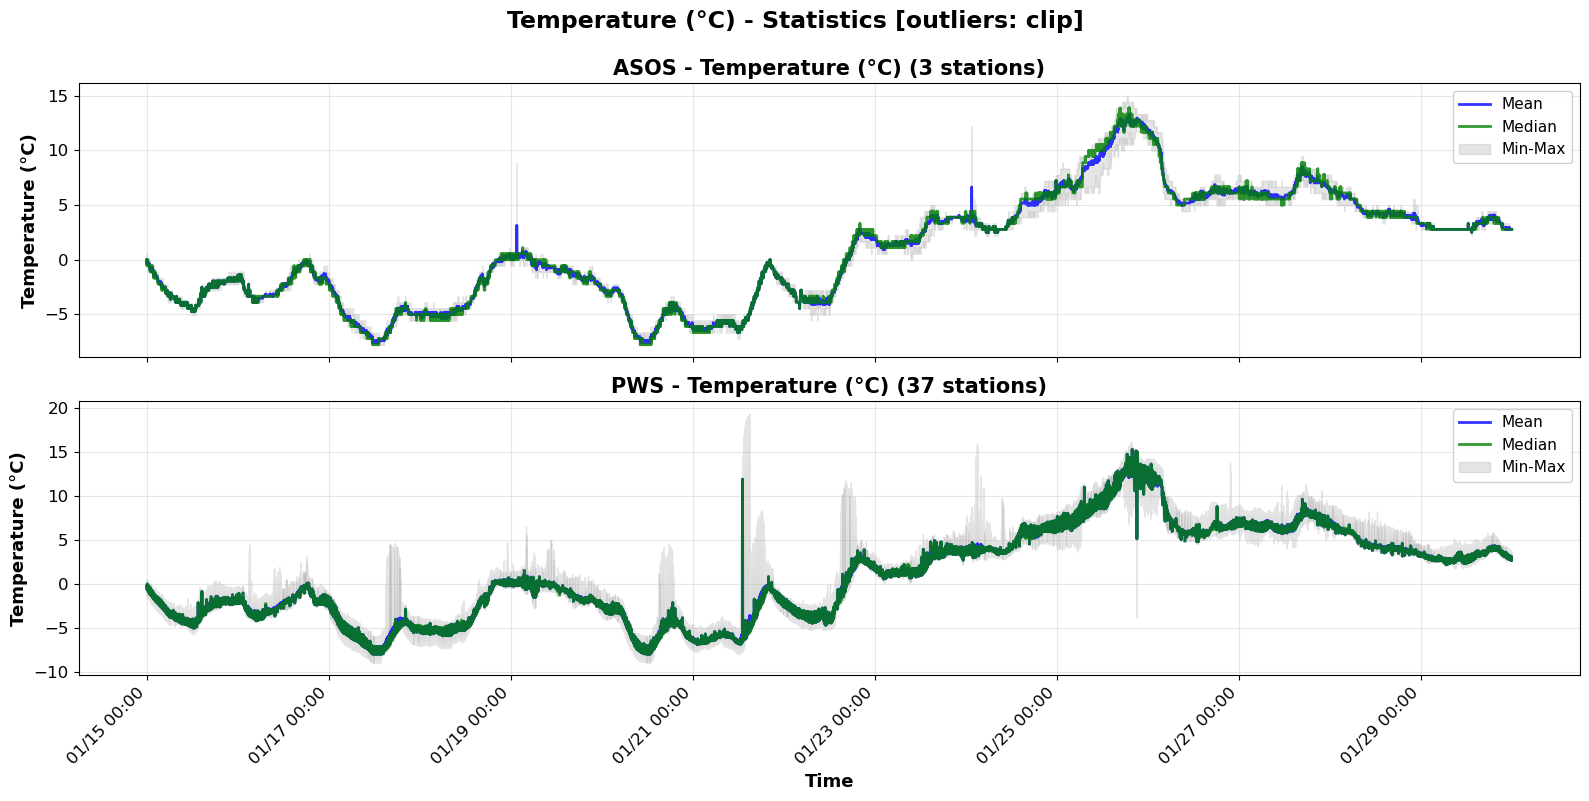

In [ ]:
plot_weather_params(
    analysis_data,
    parameter='rainfall_amount',
    mode='raw',
    max_stations=10,
    start_date=START_DATE,
    end_date=END_DATE,
)
plot_weather_params(
    analysis_data,
    parameter='rainfall_amount',
    mode='overlay',
    ylim=1,
    start_date=START_DATE,
    end_date=END_DATE,
)
plot_weather_params(
    analysis_data,
    parameter='temperature',
    start_date=START_DATE,
    end_date=END_DATE,
    mode='stats',
)




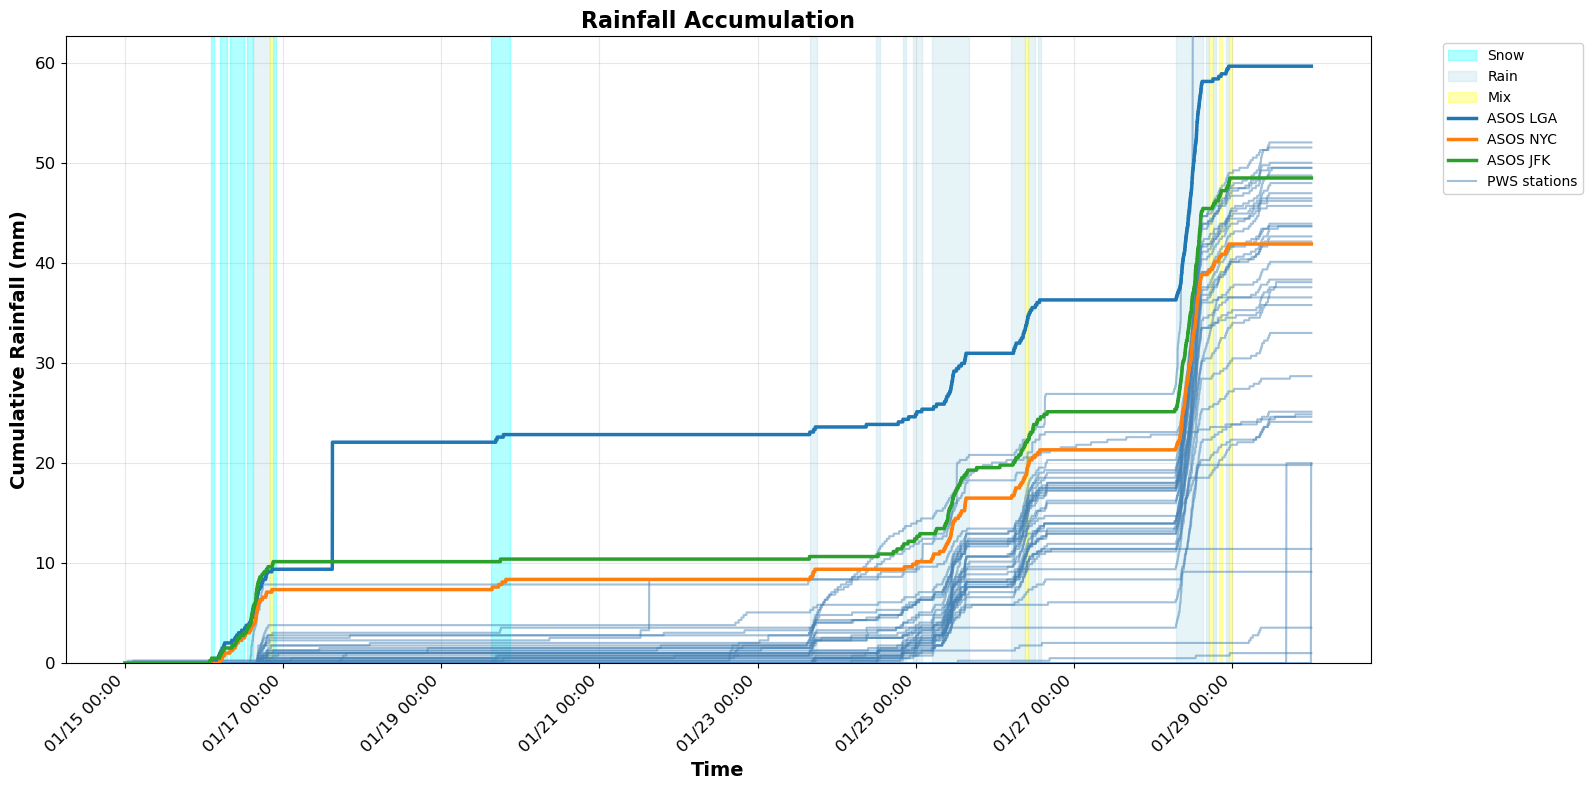

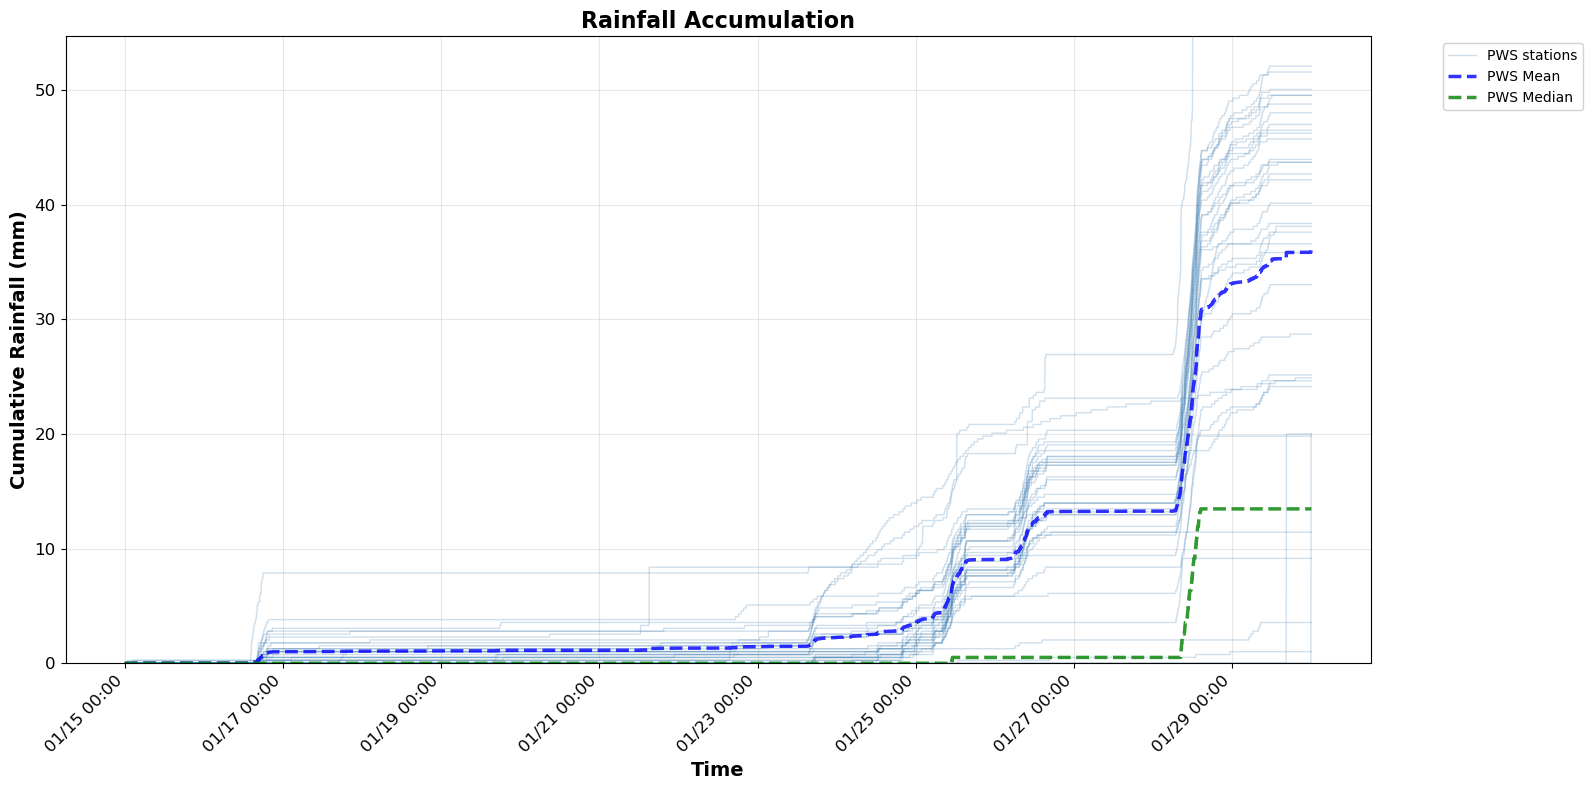

In [ ]:
fig, ax = accumulation_plot(
    analysis_data,
    date_range=(START_DATE, END_DATE),
    show_precip_grid=True
)


# PWS only with stats (individuals faded, mean/median visible)
fig, ax = accumulation_plot(
    analysis_data,
    date_range=(START_DATE, END_DATE),
    datasets='pws',
    stats=True
)

## 9. RSL Time Series

Plot Received Signal Level (RSL) time series for specific CML links to visualize signal attenuation patterns.

📅 Date range: 2024-01-15 00:00:00 to 2024-01-29 23:59:00
   Timesteps: 21600


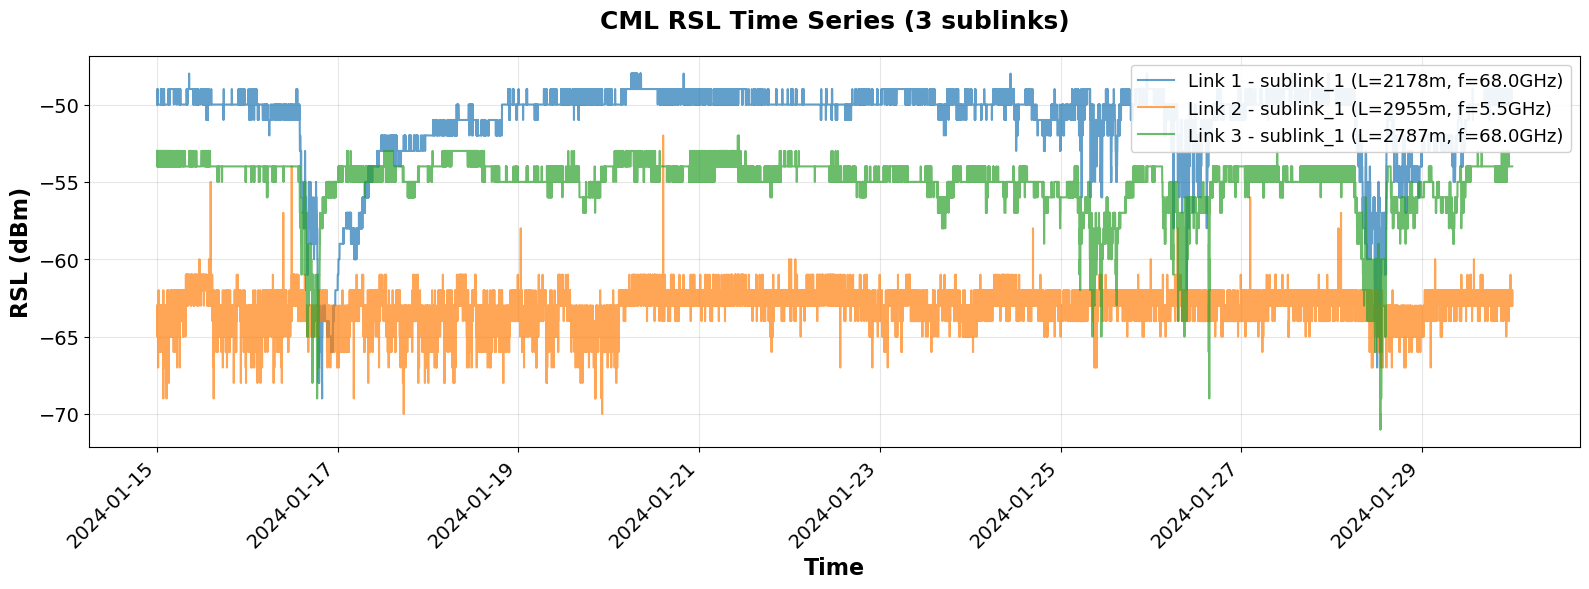

In [ ]:
plot_cml_rsl(
    ds_links,
    cml_ids=['1', '2', '3'],
    sublink_ids='sublink_1',
    date_range=(START_DATE, END_DATE),
    figsize=(16, 6)
)

plt.show()

## 10. Multipanel Plots with Matched Sensors

### 10.1. Match CML Links to PWS

In [ ]:
cml_to_pws, links_meta, pws_meta = find_nearest_pws_stations(
    ds_links=ds_links,
    links_meta=metadata['openmesh_links'],
    pws_meta=metadata['wu'],
    cml_ids= None,
    max_distance_km=5.0,
    max_stations=None,
)


ℹ No CML IDs specified - processing all 75 links in dataset

Sample link→PWS matches:
  Link 1: 10 PWS within 5.0km
  Link 2: 10 PWS within 5.0km
  ... and 73 more links

✓ Filtered network: 103 links, 36 PWS stations


In [ ]:
cml_to_pws_network, links_filtered, pws_filtered = find_nearest_pws_stations(
    ds_links=ds_links,
    links_meta=links_meta,
    pws_meta=metadata['wu'],
    cml_ids=None,
    max_distance_km=5.0,
    max_stations=None,
)
filtered_links = filter_cml_links(
    df_metadata=links_meta,
    freq_range=(5000, 7000),
    length_range=(3000, 8000),
)
cml_ids_from_meta = list(filtered_links.index)
available_cml_ids = [str(cid) for cid in ds_links.cml_id.values]
cml_ids = [cid for cid in cml_ids_from_meta if str(cid) in available_cml_ids]

cml_to_pws_network, links_filtered, pws_filtered = find_nearest_pws_stations(
    ds_links=ds_links,
    links_meta=links_meta,
    pws_meta=metadata['wu'],
    cml_ids=cml_ids,
    max_distance_km=5.0,
    max_stations=None,
)


ℹ No CML IDs specified - processing all 75 links in dataset

Sample link→PWS matches:
  Link 1: 10 PWS within 5.0km
  Link 2: 10 PWS within 5.0km
  ... and 73 more links

✓ Filtered network: 103 links, 36 PWS stations

Sample link→PWS matches:
  Link 19: 11 PWS within 5.0km
  Link 20: 12 PWS within 5.0km
  ... and 2 more links

✓ Filtered network: 7 links, 21 PWS stations


✓ Matplotlib map created


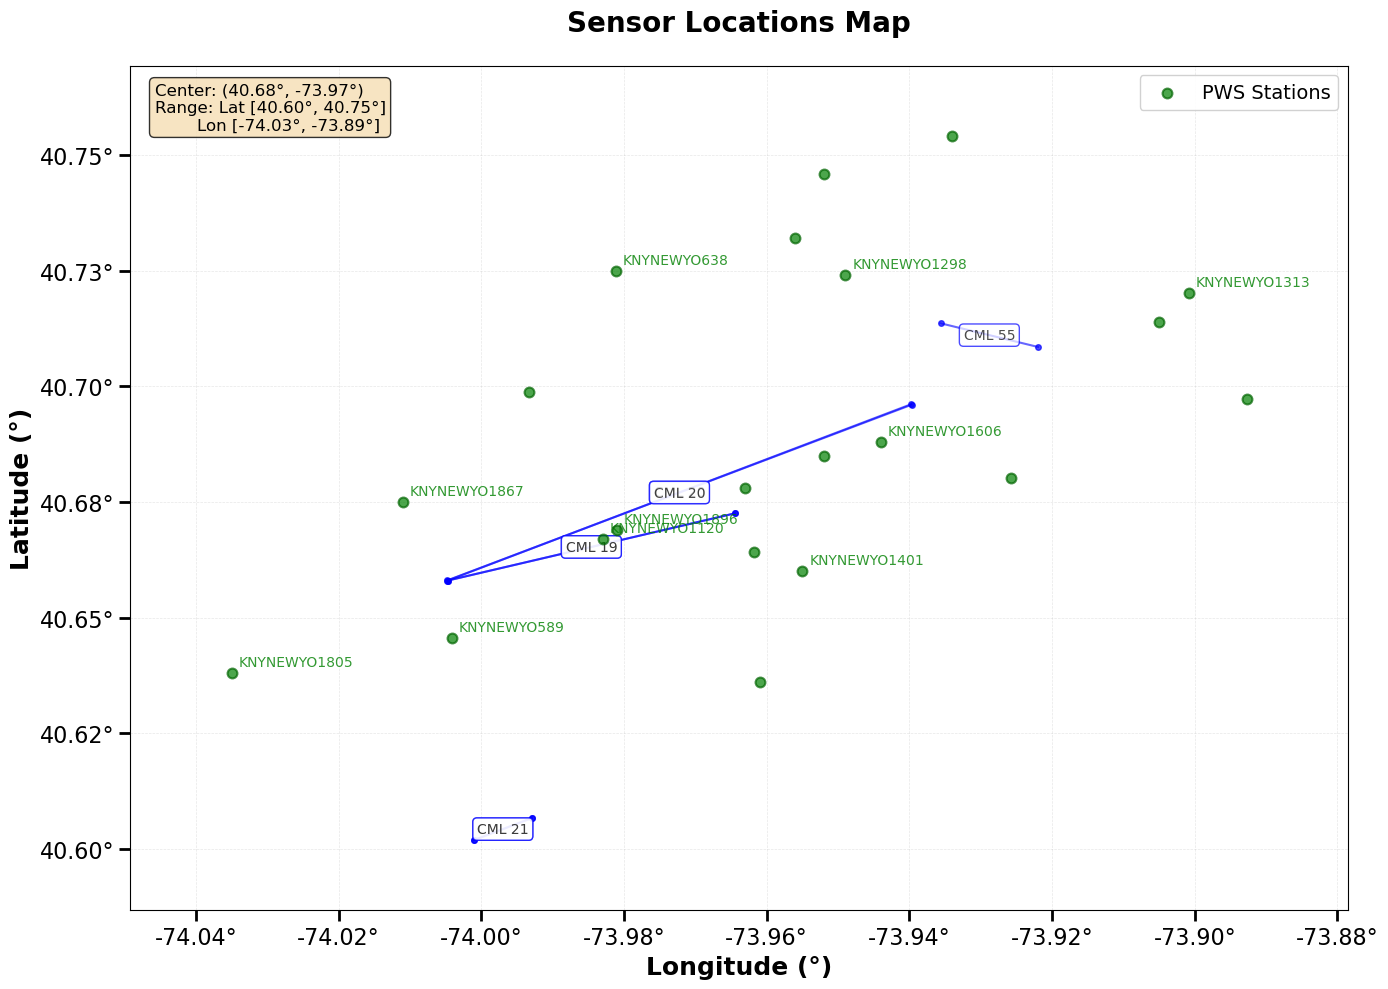

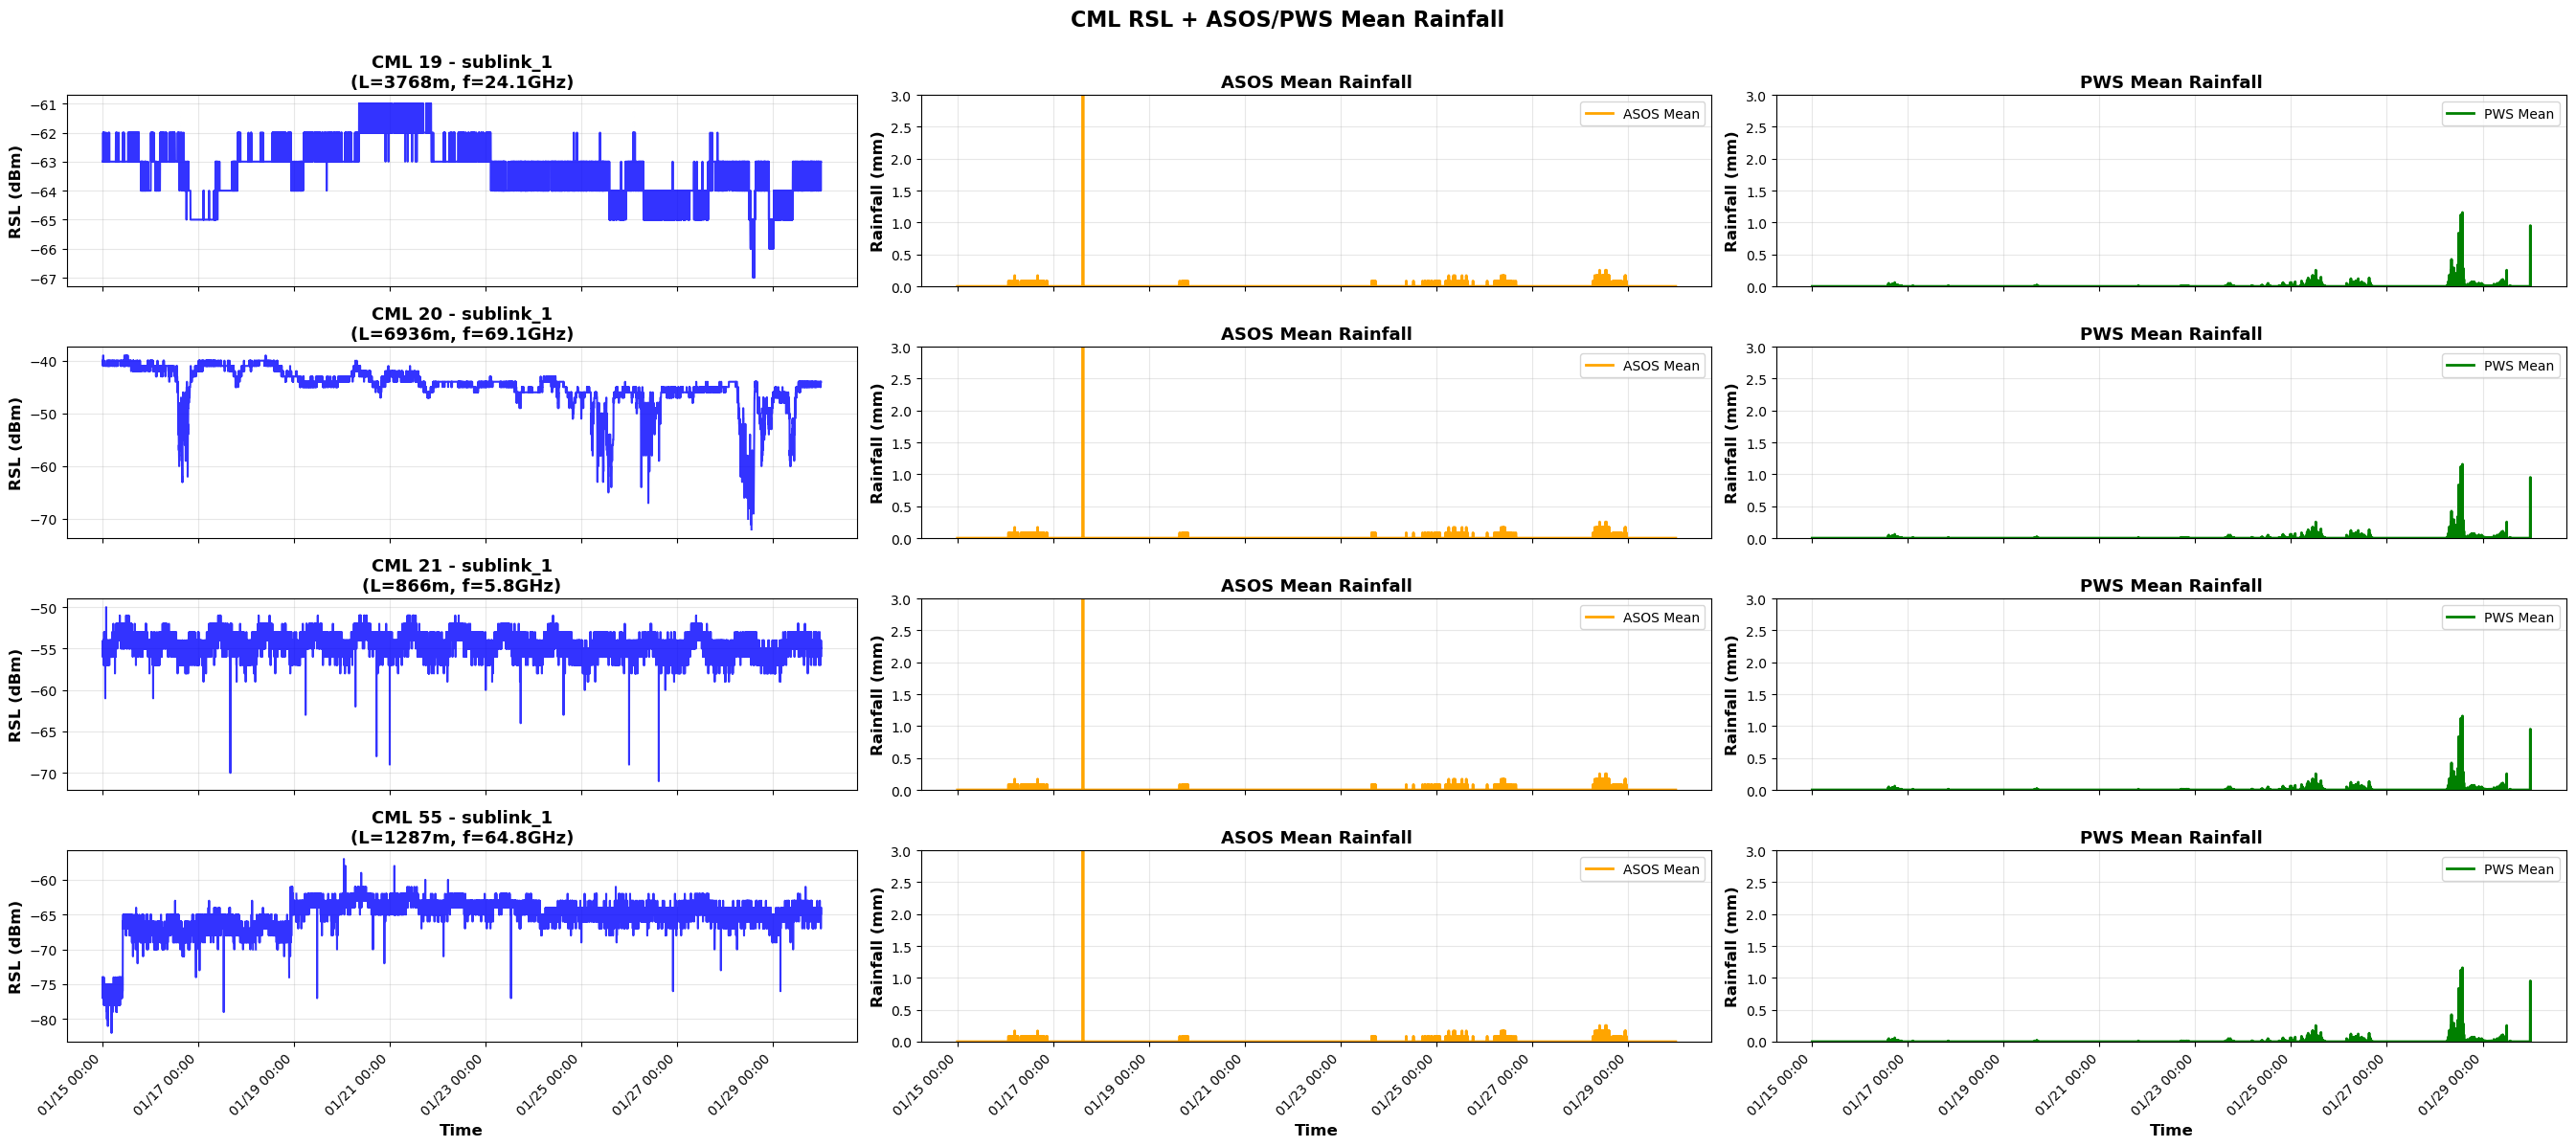

In [ ]:
display_sensors_map(
    links_meta=links_filtered,
    pws_meta=pws_filtered,
    asos_meta=None,
    show_link_labels=True,
    map_type='matplotlib',
)
fig, axes = plot_subnetwork(
    ds_links=ds_links,
    analysis_data=analysis_data,
    cml_to_pws=cml_to_pws_network,
    sublink_id='sublink_1',
    date_range=(START_DATE, END_DATE),
    figsize=(18, 12),
    y_lim=[0, 3],
)
plt.show()

### 10.2. Stacked Layout

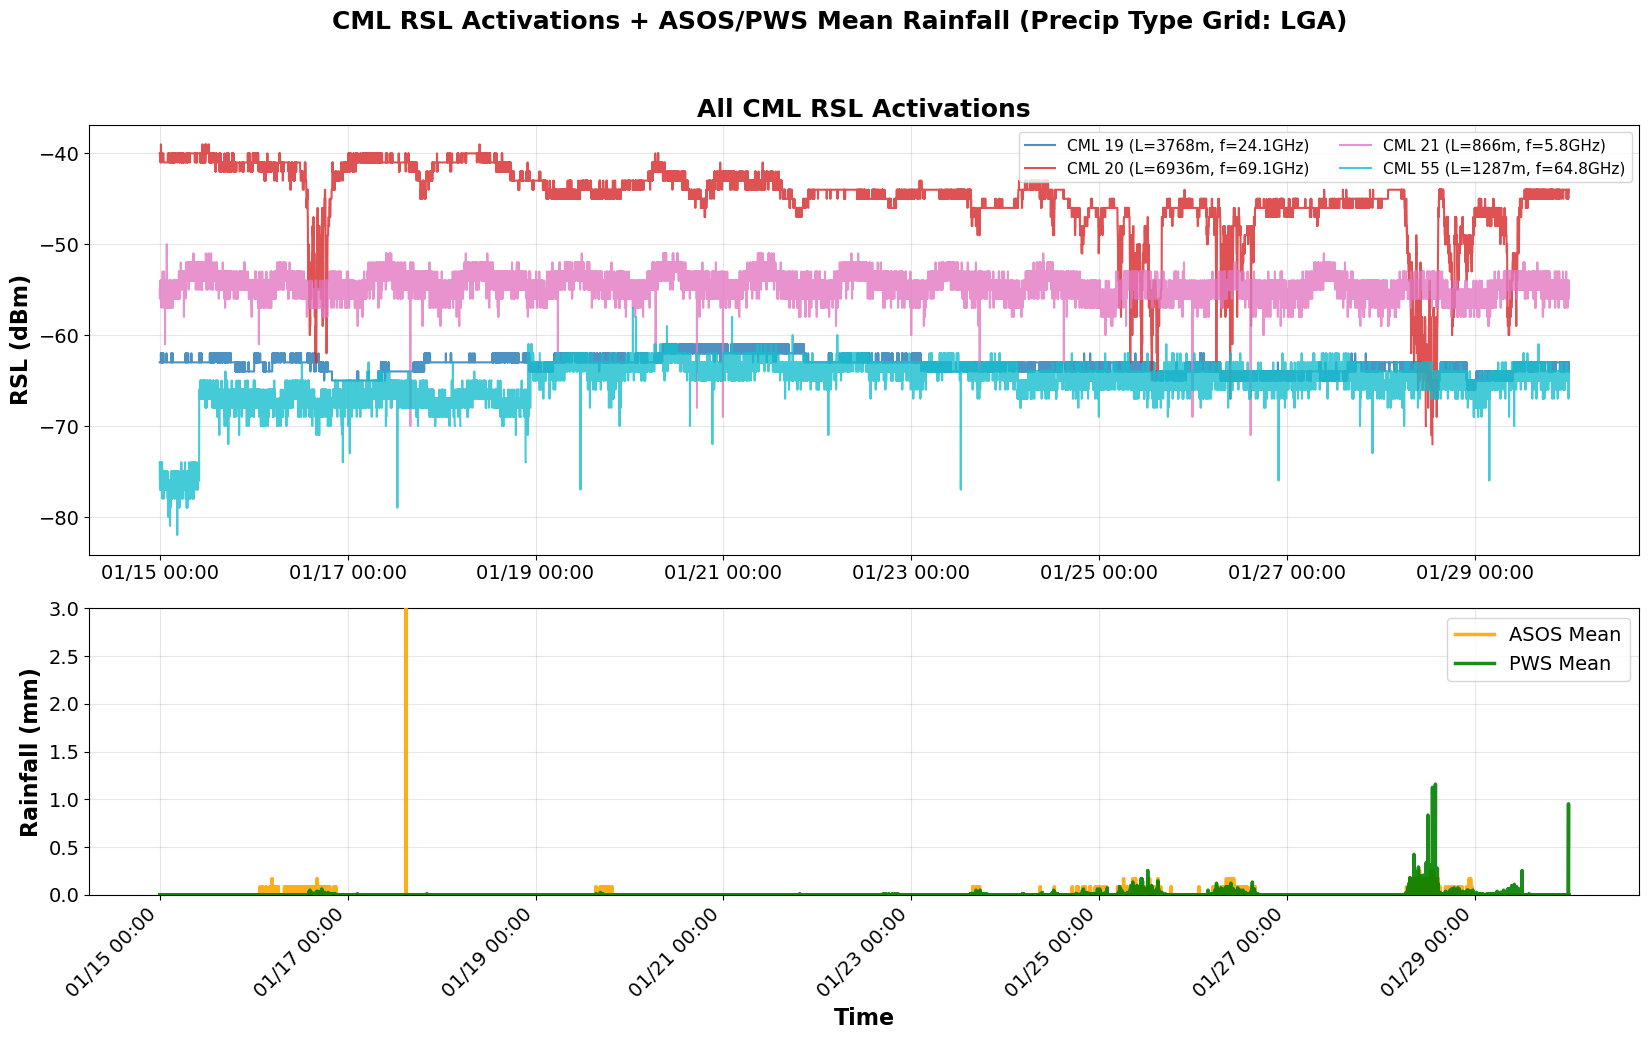

In [ ]:
fig, axes = plot_subnetwork(ds_links, analysis_data, cml_to_pws_network,
                           date_range=(START_DATE, END_DATE), plot_type='LGA',
                           layout='vertical', rainfall_source='both')

## 11. Rain Detection (Rolling STD)

CML RSL → rolling std detection; validate against PWS + ASOS rainfall.


✓ Detection: 406 periods (14.6%) | threshold=1.0 dB


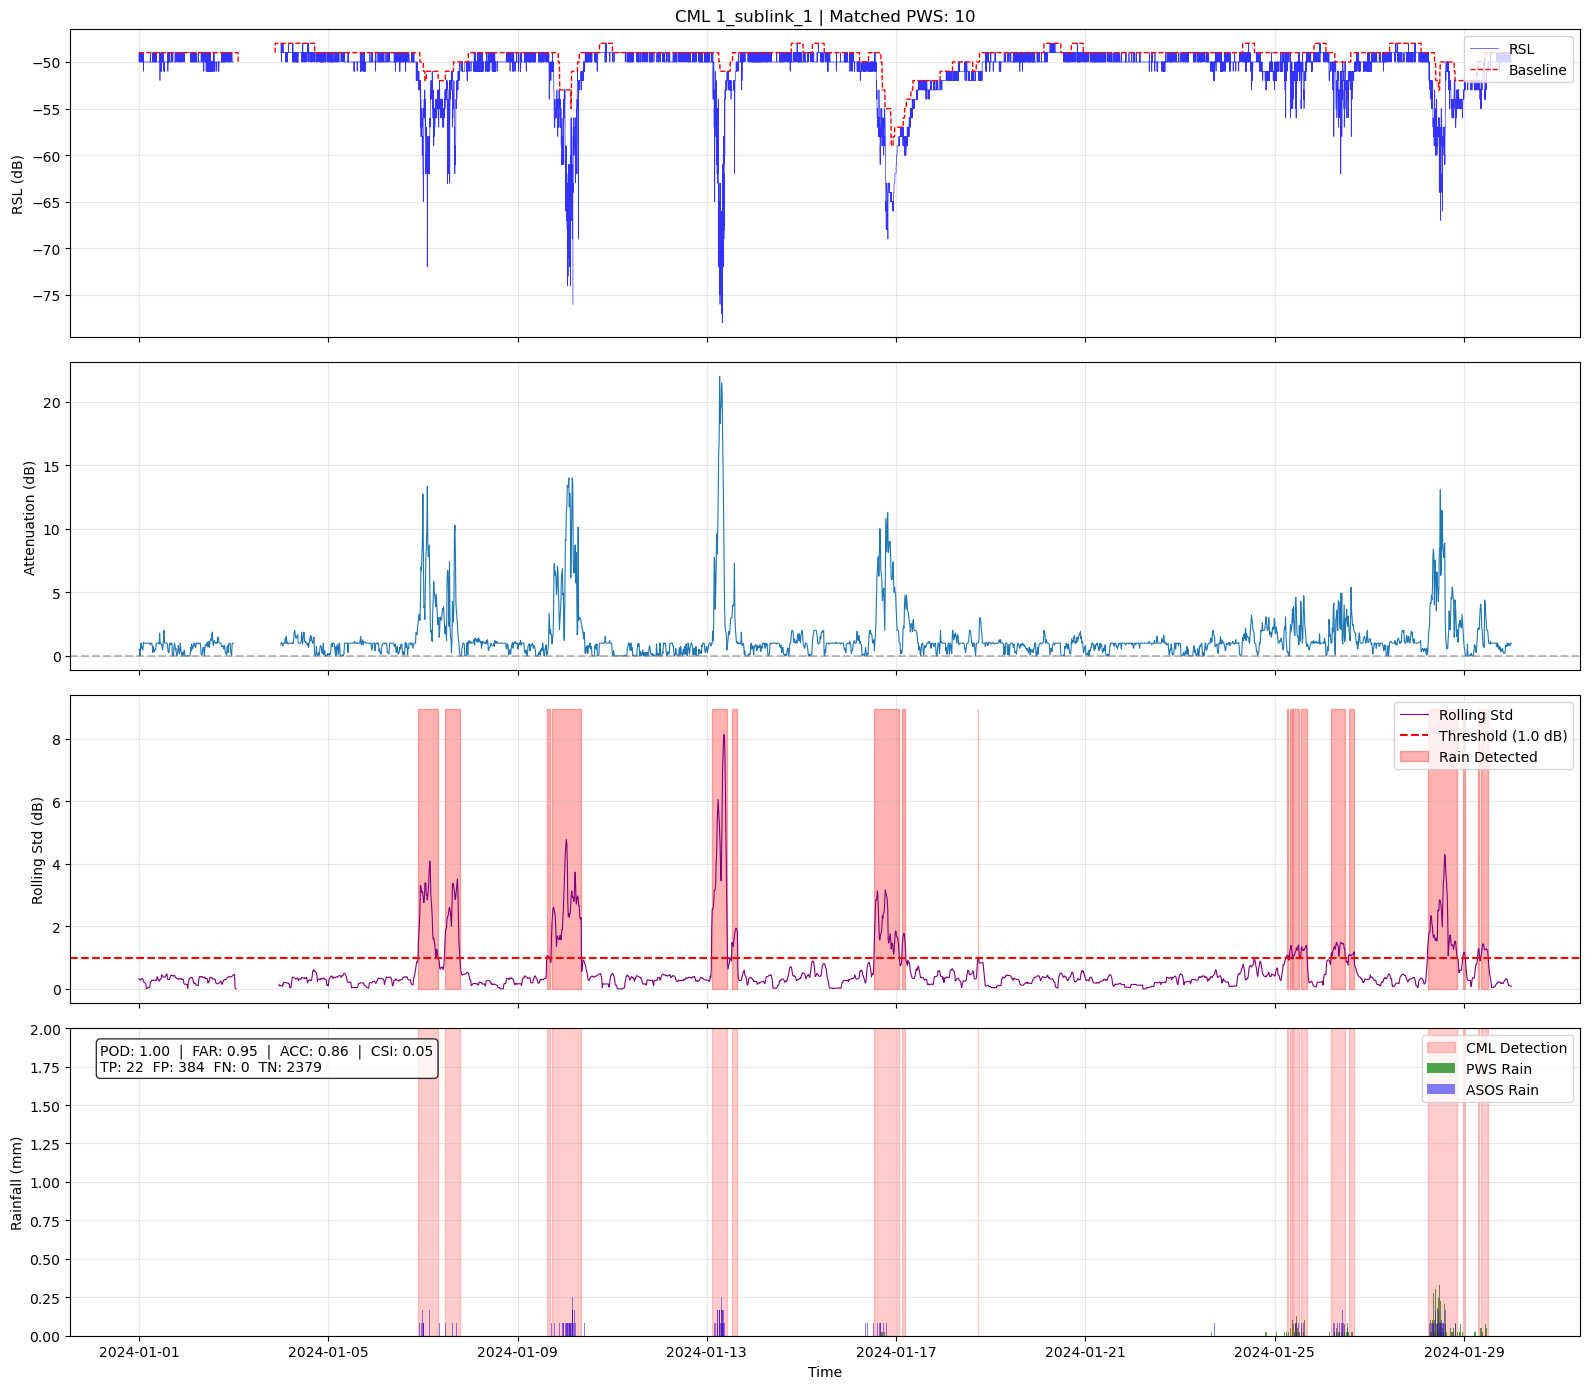


DETECTION METRICS
  POD (Hit Rate):     100.00%
  FAR (False Alarm):  94.58%
  Accuracy:           86.21%
  CSI (Threat Score): 5.42%


In [ ]:
START_DATE = datetime(2024, 1, 1)
END_DATE = datetime(2024, 1, 30)
CML_ID = '1'
SUBLINK_ID = 'sublink_1'
BASELINE_WINDOW = '6h'
BASELINE_METHOD = 'max'
DETECTION_WINDOW = '3h'
THRESHOLD = 1.0
RESAMPLE = '15min'
RAIN_Y_MAX = 2.0
SHOW_METRICS = True

df_cml, df_pws_rain, df_asos_rain, matched_pws = prepare_detection_data(
    analysis_data, CML_ID, SUBLINK_ID, cml_to_pws,
    baseline_window=BASELINE_WINDOW,
    baseline_method=BASELINE_METHOD
)

df_detection = run_rolling_std_detection(
    df_cml, window=DETECTION_WINDOW, threshold=THRESHOLD, resample=RESAMPLE
)

plot_detection_results(
    df_cml, df_detection, df_pws_rain, df_asos_rain,
    title=f'CML {CML_ID}_{SUBLINK_ID} | Matched PWS: {len(matched_pws)}',
    start_date=START_DATE,
    end_date=END_DATE,
    rain_y_max=RAIN_Y_MAX,
    show_metrics=SHOW_METRICS
)

---
## Done
